In [1]:
from data.cleaning import read_csv
from core import Config
import pandas as pd

config = Config()
all_df: pd.DataFrame = read_csv(
    filepath=config.data_dir / "datasets" / "median" / "median_imputed.csv",
    dtypes_filepath=config.data_dir / "datasets" / "median" / "median_imputed_dtypes.csv",
    index_list=[0]
)

Start global: univariate checks
On the full dataset (no grouping yet):

Plot and summarize each key numeric feature: histograms, boxplots, min/median/max, IQR.

Compute simple outlier heuristics per feature:

- IQR fences
- Z‑scores

This gives you a first feel for which features are “messy” and where to focus.

Minimum value: 0.0
Maximum value: 1577287.06624606
Median value: 27.130075951896
IQR value: TR.AnalyticCO2    53.489406
dtype: Float64 Z-score:         Z-score
0      0.007695
1      0.016120
2     -0.024781
3     -0.025134
4     -0.026204
...         ...
25627 -0.026054
25628 -0.025053
25629 -0.025384
25630 -0.023919
25631 -0.024340

[25632 rows x 1 columns]


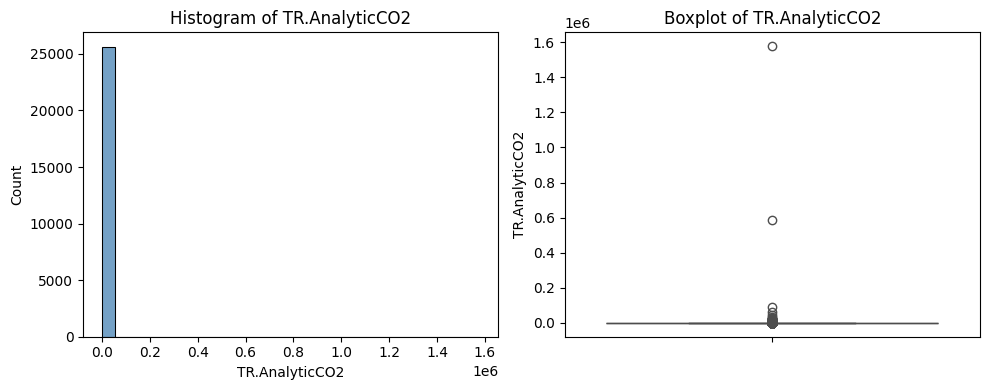

In [2]:
num_cols: list[str] = all_df.select_dtypes('number').columns.to_list()
remove_columns: set[str] = {
    'Date',
    'TR.AnalyticAntiTakeoverDevices',
    'TR.AnalyticAntiCompetitionControvScore',
    'TR.AnalyticAuditCommExpertiseScore',
    'TR.AnalyticAuditCommMgtIndScore,',
    'TR.AnalyticBoardAttendanceScore',
    'TR.AnalyticBoardFunctionsPolicyScore',
    'TR.AnalyticBoardReelectionScore',
    'TR.AnalyticBoardSizeMore10Less8',
    'TR.AnalyticBoardSizeMore10Less8Score',
    'TR.AnalyticBoardStructurePolicyScore',
    'TR.BoardExternalConsultantsScore',
    'TR.BoardSuccessionPlanScore',
    'TR.AnalyticExperiencedBoard',
    'TR.AnalyticCustomerControvScore',
    'TR.AnalyticBoardFemale',
    'TR.AnalyticBoardSpecificSkills',
    'TR.AnalyticIndepBoard',
    'TR.AnalyticNonExecBoard',
    'TR.AnalyticBoardAffiliations',
    'TR.AnalyticAuditCommMgtIndScore',
    'TR.AnalyticCEOChairmanSeparationScore',
}
num_cols = list(set(num_cols) - remove_columns)
num_cols.sort()
feature = num_cols[6]

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats.mstats as mstats

def hist_and_box_sns(df, column, bins=40):
    fig, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

    sns.histplot(data=df, x=column, bins=bins, ax=ax_hist, kde=False, color="steelblue")
    ax_hist.set_title(f"Histogram of {column}")

    sns.boxplot(y=df[column], ax=ax_box, orient="v", color="orange")
    ax_box.set_title(f"Boxplot of {column}")

    fig.tight_layout()
    return fig, (ax_hist, ax_box)

fig, axes = hist_and_box_sns(all_df, feature, bins=30)
minimum_value = all_df[[feature]].min().values[0]
maximum_value = all_df[[feature]].max().values[0]
median_value = all_df[[feature]].median().values[0]
iqr_value = all_df[[feature]].quantile(0.75) - all_df[[feature]].quantile(0.25)
z_score: pd.DataFrame = pd.DataFrame(mstats.zscore(all_df[[feature]]), columns=['Z-score'])
print(f"Minimum value: {minimum_value}\nMaximum value: {maximum_value}\nMedian value: {median_value}\nIQR value: {iqr_value} Z-score: {z_score}")
feature_df = all_df[['Instrument', 'Date', feature]].join(z_score, how='outer')

thr = 3
mask_outlier = feature_df['Z-score'].abs() > thr

# companies with at least one outlier for that feature
companies_with_outlier = feature_df.loc[mask_outlier, 'Instrument'].unique()

# subset: all years for those companies
df_focus = feature_df[feature_df['Instrument'].isin(companies_with_outlier)]
df_focus.sort_values(['Instrument', 'Date'], inplace=True)